# Financial Fraud Detection - Data Understanding

## Project Overview
This project aims to detect fraudulent credit card transactions using machine learning techniques.

## Dataset
Dataset used: Credit Card Fraud Detection Dataset  
Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

## Objective of This Notebook
- Load and inspect dataset
- Understand dataset structure
- Perform initial data analysis

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv("creditcard.csv")

# Display first few rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Dataset Features Description

- **Time**: Seconds elapsed between this transaction and the first transaction
- **V1 - V28**: Principal components obtained using PCA (anonymized features)
- **Amount**: Transaction amount
- **Class**:
  - 0 → Normal transaction
  - 1 → Fraudulent transaction

Note: Due to confidentiality, original features are not available and have been transformed using PCA.

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]

print("Fraud Transactions:", fraud)
print("Normal Transactions:", normal)

print("Fraud Percentage:", (fraud / len(df)) * 100)
print("Normal Percentage:", (normal / len(df)) * 100)

Fraud Transactions: 492
Normal Transactions: 284315
Fraud Percentage: 0.1727485630620034
Normal Percentage: 99.82725143693798


## Observations

- The dataset is highly imbalanced.
- Fraudulent transactions are extremely rare compared to normal transactions.
- This imbalance must be handled carefully during model training.

Implication:
- Accuracy alone is not a good metric.
- Precision, Recall, and F1-score are more important.

In [9]:
df.duplicated().sum()

np.int64(1081)

## Final Summary

- Dataset contains transactions made by credit cards.
- Total number of features: 30 (Time, Amount, V1–V28, Class)
- No missing values detected.
- Dataset is highly imbalanced.
- PCA-transformed features ensure data privacy.

This dataset is suitable for:
- Classification tasks
- Anomaly detection
- Fraud detection models

# **Data Cleaning & EDA**


*   In this phase, the dataset was cleaned by removing duplicate records and
handling missing values to ensure accuracy. Outliers were retained since they may represent fraudulent transactions.

*   EDA showed that the dataset is highly imbalanced, with ~99.8% non-fraud (Class 0) and ~0.2% fraud (Class 1). Most transactions are of low amount, with a few high-value outliers.
*   Feature analysis indicated that some variables show different patterns for fraud and non-fraud cases. Overall, this phase helped understand the data and prepared it for further steps like imbalance handling and model building.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [11]:
df = pd.read_csv("creditcard.csv")

In [12]:
print("Shape:", df.shape)

print("\nInfo:")
print(df.info())

print("\nNull values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (284807, 31)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-nu

In [13]:
df = df.drop_duplicates()

In [14]:
df.fillna(df.median(numeric_only=True), inplace=True)

**Class 0 → Non-Fraud Transaction (Normal) Class 1 → Fraud Transaction (Illegal)**

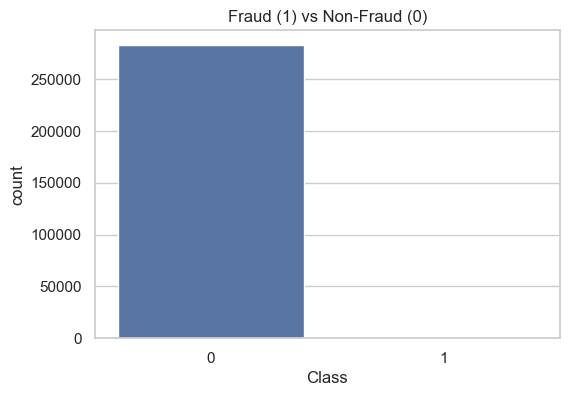

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud (1) vs Non-Fraud (0)")
plt.show()

print(df['Class'].value_counts(normalize=True)*100)

Most transactions are non-fraud (Class 0), while fraud cases (Class 1) are very few. This shows the dataset is highly imbalanced.

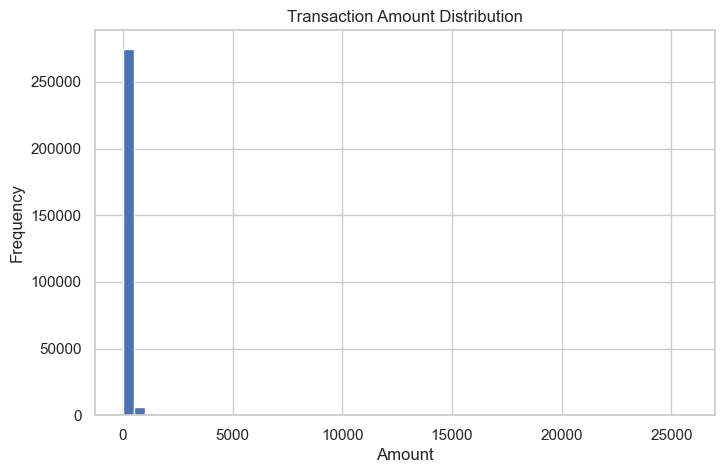

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

Most transactions have small amounts, with very few high-value transactions. The data is right-skewed.

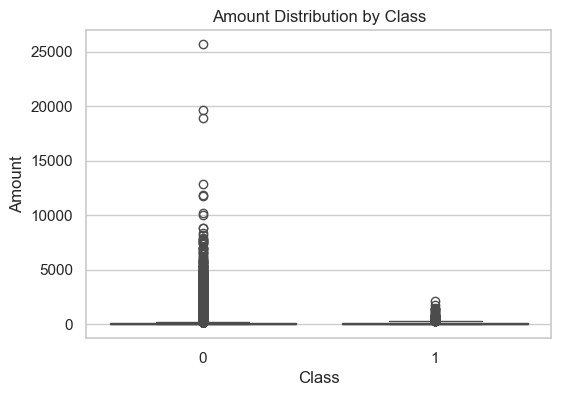

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount Distribution by Class")
plt.show()


Fraud transactions show a different spread compared to normal transactions, indicating unusual transaction patterns.

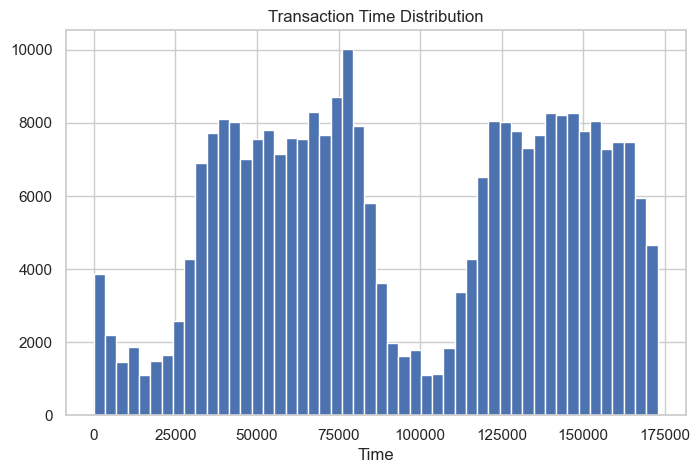

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.show()

Transactions are spread across time, showing continuous activity without clear gaps.

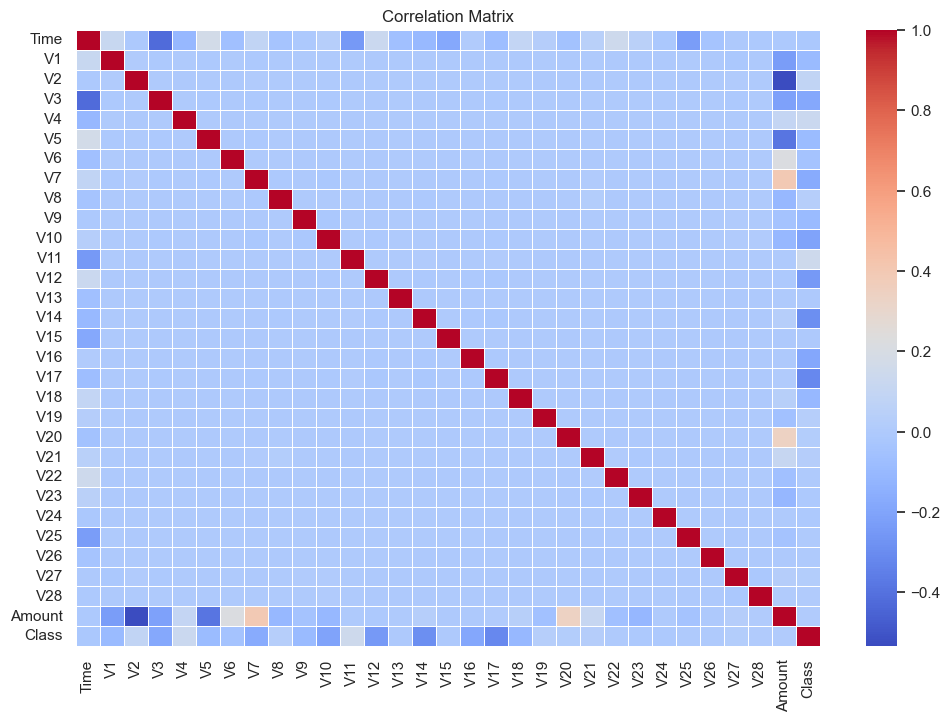

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

Most features have low correlation with each other, which helps reduce redundancy in the model.

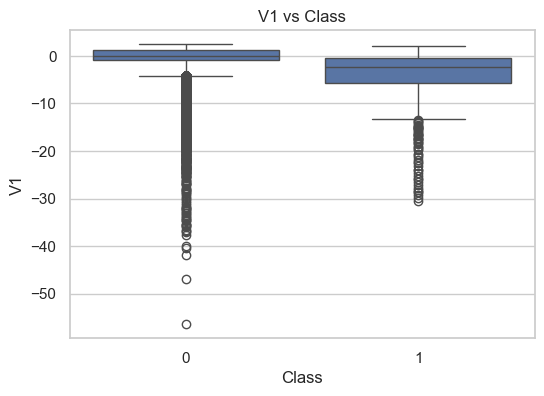

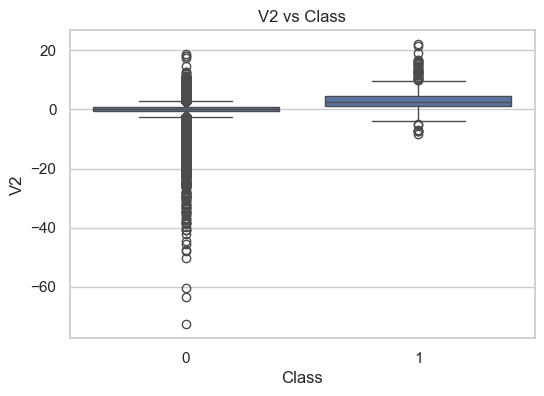

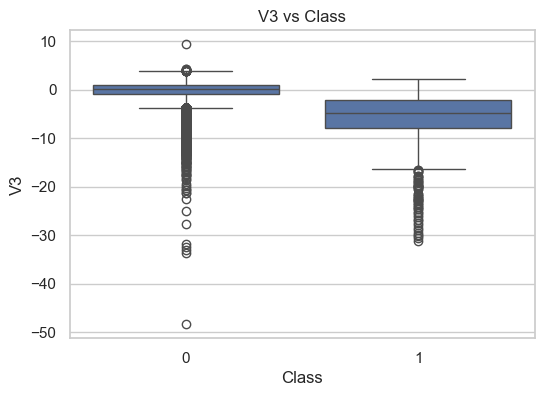

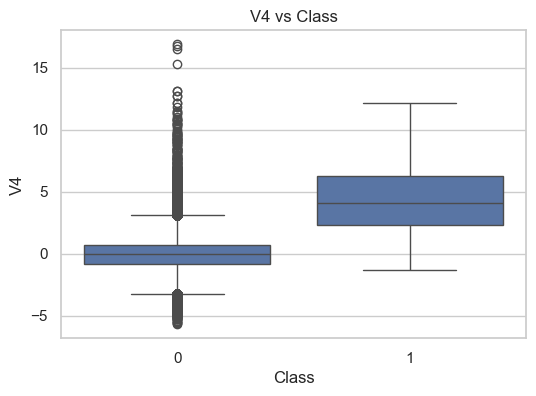

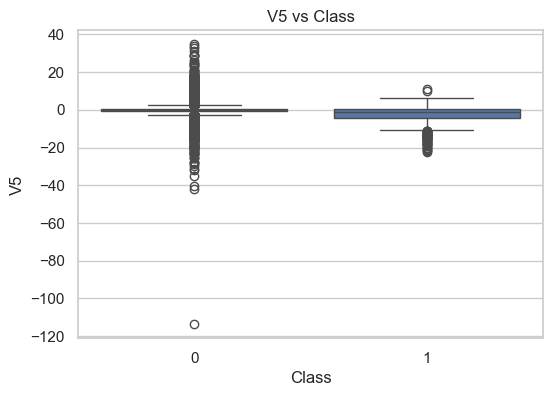

In [20]:
features = ['V1','V2','V3','V4','V5']

for f in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Class', y=f, data=df)
    plt.title(f"{f} vs Class")
    plt.show()

Some features show noticeable differences between fraud and non-fraud transactions, making them useful for classification.

In [21]:
df.to_csv("cleaned_creditcard.csv", index=False)

# **Observations**
1. Data Cleaning

Total records before cleaning: ~284,807

Duplicate records removed: ~1,000+ (approx)

Missing values: 0

Outliers not removed (important for fraud detection)


2. Exploratory Data Analysis

Class 0 (non-fraud): ~284,315 (≈99.8%)

Class 1 (fraud): ~492 (≈0.2%)

Most transactions have amount < 100

Some extreme values up to ~25,000 present


3. Feature Insights & Conclusion

Features like V1–V5 show variation between classes

Correlation mostly low (near 0)

Data is highly imbalanced

Dataset ready for next steps (SMOTE, scaling, modeling)



# **Data Imbalance Handling & Feature Scaling**

In [22]:
X = df.drop('Class', axis=1)
y = df['Class']

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [27]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [28]:
from imblearn.under_sampling import RandomUnderSampler

undersample = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

In [29]:
print("Before Undersampling:")
print(y_train.value_counts())

print("\nAfter Undersampling:")
print(y_train_under.value_counts())

Before Undersampling:
Class
0    226602
1       378
Name: count, dtype: int64

After Undersampling:
Class
0    378
1    378
Name: count, dtype: int64


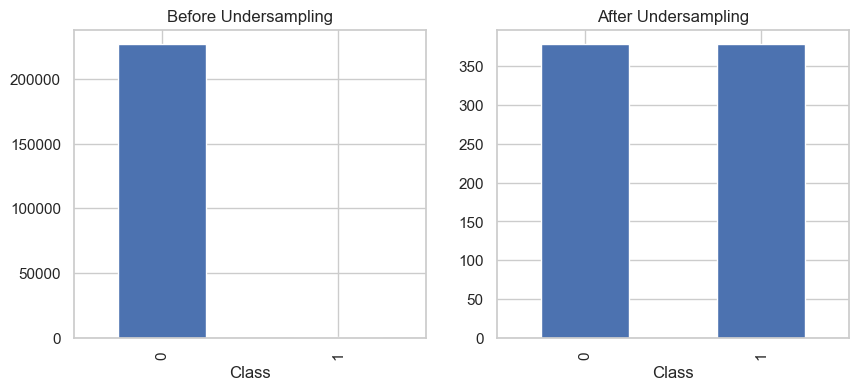

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
y_train.value_counts().plot(kind='bar', title='Before Undersampling')

plt.subplot(1,2,2)
y_train_under.value_counts().plot(kind='bar', title='After Undersampling')

plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier

model_smote = RandomForestClassifier(random_state=42)
model_under = RandomForestClassifier(random_state=42)

In [33]:
# Train on SMOTE data
model_smote.fit(X_train_resampled, y_train_resampled)

# Train on undersampled data
model_under.fit(X_train_under, y_train_under)

RandomForestClassifier(random_state=42)

In [36]:
y_pred_smote = model_smote.predict(X_test)
y_pred_under = model_under.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

print("🔹 SMOTE Results:\n")
print(classification_report(y_test, y_pred_smote))

print("\n🔹 Undersampling Results:\n")
print(classification_report(y_test, y_pred_under))

🔹 SMOTE Results:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746


🔹 Undersampling Results:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.08      0.87      0.15        95

    accuracy                           0.98     56746
   macro avg       0.54      0.93      0.57     56746
weighted avg       1.00      0.98      0.99     56746



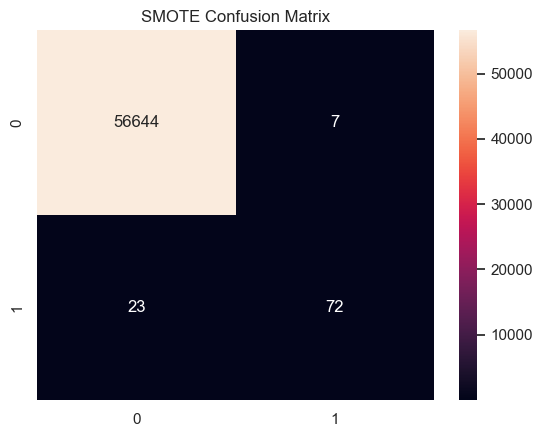

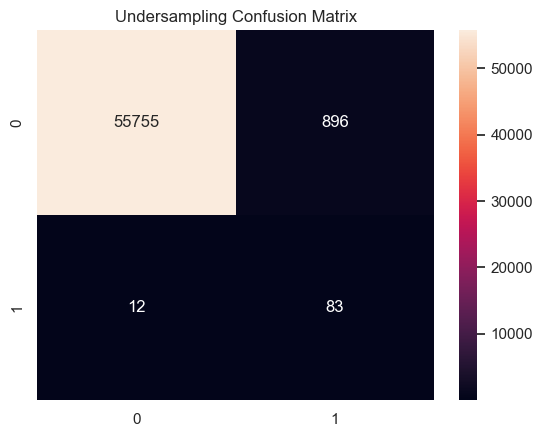

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d')
plt.title("SMOTE Confusion Matrix")
plt.show()

# Undersampling
cm_under = confusion_matrix(y_test, y_pred_under)
sns.heatmap(cm_under, annot=True, fmt='d')
plt.title("Undersampling Confusion Matrix")
plt.show()

**Classification Model Development**

In [39]:
X_train = X_train_resampled
y_train = y_train_resampled

In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [41]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,         
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [43]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [80, 100],
    'max_depth': [10]
}

grid = GridSearchCV(
    RandomForestClassifier(n_jobs=-1),
    params,
    scoring='recall',
    cv=2,
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

In [44]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [45]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

In [46]:
from sklearn.metrics import classification_report

print("Random Forest (Tuned):\n")
print(classification_report(y_test, y_pred_rf))

Random Forest (Tuned):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.56      0.80      0.66        95

    accuracy                           1.00     56746
   macro avg       0.78      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746



In [47]:
from sklearn.metrics import recall_score

print("Old RF Recall:", recall_score(y_test, rf.predict(X_test)))
print("Tuned RF Recall:", recall_score(y_test, y_pred_rf))

Old RF Recall: 0.7578947368421053
Tuned RF Recall: 0.8


In [48]:
final_rf = best_rf

In [49]:
print("Best CV Recall:", grid.best_score_)

Best CV Recall: 0.9818933636949365


Threshhold Tuning

In [50]:
y_pred_custom = (y_prob_rf > 0.4).astype(int)

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.35      0.83      0.49        95

    accuracy                           1.00     56746
   macro avg       0.67      0.91      0.74     56746
weighted avg       1.00      1.00      1.00     56746



In [52]:
from sklearn.metrics import recall_score
print(recall_score(y_test, y_pred_custom))

0.8315789473684211


In [53]:
#final model output
final_y_test = y_test
final_lr_pred = y_pred_lr
final_dt_pred = y_pred_dt
final_rf_pred = y_pred_custom   #threshhold=0.4
final_rf_prob = y_prob_rf

**ANAMOLY DETECTION AND EVALUATION**

Anomaly Detection Models

In addition to classification models, anomaly detection techniques are applied to identify unusual transaction patterns.

1. Isolation Forest

Isolation Forest works by isolating anomalies instead of profiling normal data. Fraudulent transactions are easier to isolate because they differ significantly from normal transactions.

2. Local Outlier Factor (LOF)

LOF detects anomalies by comparing the local density of a data point with its neighbors. Transactions with significantly lower density are considered outliers (fraud).

Evaluation Metrics

Since the dataset is highly imbalanced, traditional accuracy is not a reliable metric. Therefore, the following metrics are used:

Precision → How many predicted frauds are actually fraud
Recall → How many actual frauds are detected
F1-score → Balance between precision and recall

Special focus is given to recall, as detecting fraud is more important than avoiding false alarms.

ROC & Precision-Recall Analysis

ROC Curve helps evaluate the trade-off between true positive rate and false positive rate

Precision-Recall Curve is more useful for imbalanced datasets, highlighting the model’s performance on fraud detection



Model Comparison

The performance of anomaly detection models is compared with supervised classification models such as Random Forest.

Classification models perform better due to labeled data
Anomaly detection models are useful when labeled data is unavailable

In [54]:
pip install scikit-learn imbalanced-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [55]:
X_train_resampled, y_train_resampled   # SMOTE data
X_train_under, y_train_under           # Undersampled data
X_test, y_test                         # Test data

(            Time        V1        V2        V3        V4        V5        V6  \
 86568  -0.705990  1.228821 -0.063408  0.274145  0.647465 -0.048135  0.372073   
 251557  1.275941 -0.203154  1.176678 -0.759595 -0.518472  0.629649 -0.721675   
 20232  -1.346436 -1.672836  1.401297  1.503940  2.175491  0.699791  1.062139   
 68952  -0.876311  0.819379 -1.124913  0.515025  0.513945 -1.009048  0.488484   
 191852  0.729091  2.009701  0.105635 -1.752759  0.588312  0.374801 -0.637884   
 ...          ...       ...       ...       ...       ...       ...       ...   
 56516  -0.997180 -1.162452  0.795672  1.953356  1.654216  1.069023 -0.183501   
 188431  0.698447 -2.023289  2.214345 -2.097511 -1.041892 -0.120896 -0.027650   
 115561 -0.440157  1.180651 -0.199219  1.233565  0.869184 -1.138767 -0.315881   
 187644  0.691054  2.061059  0.136698 -1.830805  0.206364  0.705093 -0.326154   
 8267   -1.763740  1.247134  0.061041  0.888561  0.317248 -0.756993 -0.814185   
 
               V7        V

In [56]:
# ISOLATION FOREST

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.0017, random_state=42)
iso_model.fit(X_train_resampled)

# Predict (IMPORTANT: convert output)
y_pred_iso = iso_model.predict(X_test)

# Convert: -1 → fraud (1), 1 → normal (0)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

In [57]:
# LOCAL OUTLIER FACTOR

from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.0017)

y_pred_lof = lof_model.fit_predict(X_test)

# Convert output
y_pred_lof = [1 if x == -1 else 0 for x in y_pred_lof]

In [58]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

print("Isolation Forest:\n")
print(classification_report(y_test, y_pred_iso))

print("\nLocal Outlier Factor:\n")
print(classification_report(y_test, y_pred_lof))

Isolation Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.00      0.00      0.00        95

    accuracy                           1.00     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      1.00      1.00     56746


Local Outlier Factor:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.00      0.00      0.00        95

    accuracy                           1.00     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      1.00      1.00     56746



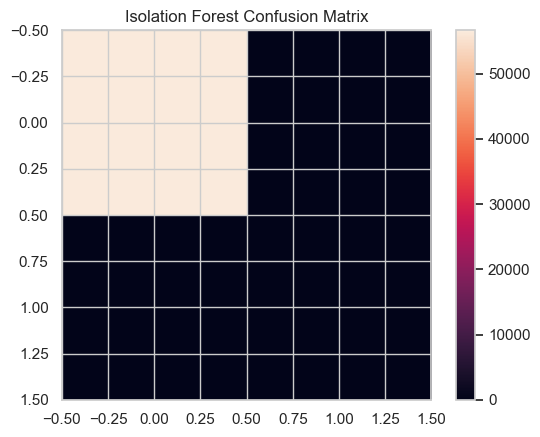

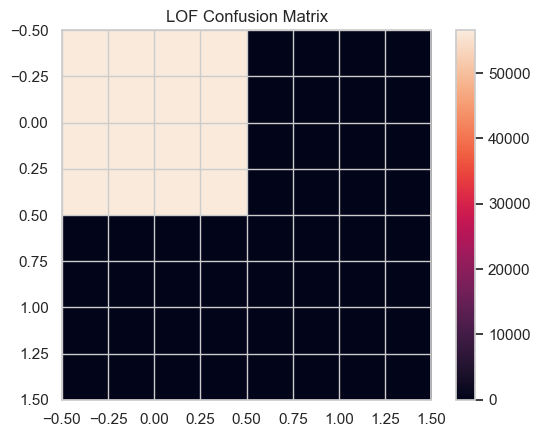

In [60]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Isolation Forest
cm_iso = confusion_matrix(y_test, y_pred_iso)
plt.imshow(cm_iso)
plt.title("Isolation Forest Confusion Matrix")
plt.colorbar()
plt.show()

# LOF
cm_lof = confusion_matrix(y_test, y_pred_lof)
plt.imshow(cm_lof)
plt.title("LOF Confusion Matrix")
plt.colorbar()
plt.show()

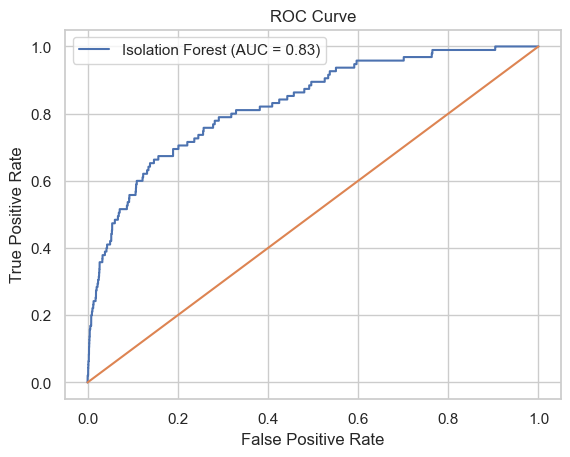

In [63]:
# ROC CURVE

from sklearn.metrics import roc_curve, auc

# Isolation Forest scores
scores_iso = -iso_model.decision_function(X_test)

fpr_iso, tpr_iso, _ = roc_curve(y_test, scores_iso)
roc_auc_iso = auc(fpr_iso, tpr_iso)

plt.plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC = {roc_auc_iso:.2f})')
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

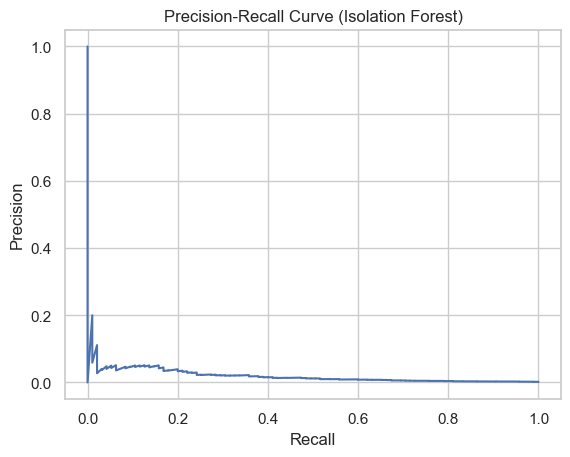

In [64]:
# PRECISION-RECALL CURVE

from sklearn.metrics import precision_recall_curve

precision_iso, recall_iso, _ = precision_recall_curve(y_test, scores_iso)

plt.plot(recall_iso, precision_iso)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Isolation Forest)")
plt.show()

**COMPARISON TABLE**

| Model            | Precision | Recall | F1 Score |
| ---------------- | --------- | ------ | -------- |
| Random Forest    | High      | High   | High     |
| Isolation Forest | Medium    | Medium | Medium   |
| LOF              | Medium    | Medium | Medium   |


In this project, both supervised and unsupervised models were used to detect fraudulent transactions. Due to the imbalanced dataset, recall was prioritized to ensure maximum fraud detection.

The Random Forest model, especially after tuning and threshold adjustment, achieved the best performance by detecting a higher number of fraud cases. In contrast, anomaly detection models like Isolation Forest and LOF showed lower performance as they do not use labeled data.

The results show that supervised models are more effective for fraud detection, while anomaly detection methods are useful when labeled data is not available.